In [1]:
# Import library utama
import pandas as pd

# Baca dataset Netflix
df = pd.read_csv("/content/netflix_titles.csv")

# Tampilkan 5 data pertama
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
# Ukuran dataset
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

# Nama-nama kolom
print("\nNama kolom:")
print(df.columns.tolist())

# Info tipe data
print("\nInformasi dataset:")
print(df.info())

# Cek data yang hilang (missing values)
print("\nJumlah missing value per kolom:")
print(df.isnull().sum())


Jumlah baris: 8807
Jumlah kolom: 12

Nama kolom:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

Jumlah missing value per kolom:
show_

In [3]:
# Rencana eksplorasi data
eda_plan = {
    "Tujuan EDA": "Memahami karakteristik tayangan di Netflix, termasuk jenis, distribusi tahun rilis, negara asal, dan genre populer.",
    "Pertanyaan EDA": [
        "1. Berapa banyak film dan TV Show yang tersedia di Netflix?",
        "2. Bagaimana distribusi tahun rilis tayangan di Netflix?",
        "3. Negara mana yang paling banyak memproduksi konten di Netflix?",
        "4. Apa genre (listed_in) yang paling sering muncul?",
        "5. Seberapa banyak rating penonton seperti 'TV-MA', 'PG-13', dll?",
    ]
}

# Cetak rencana EDA
for key, value in eda_plan.items():
    print(f"{key}:")
    if isinstance(value, list):
        for item in value:
            print("  -", item)
    else:
        print(value)


Tujuan EDA:
Memahami karakteristik tayangan di Netflix, termasuk jenis, distribusi tahun rilis, negara asal, dan genre populer.
Pertanyaan EDA:
  - 1. Berapa banyak film dan TV Show yang tersedia di Netflix?
  - 2. Bagaimana distribusi tahun rilis tayangan di Netflix?
  - 3. Negara mana yang paling banyak memproduksi konten di Netflix?
  - 4. Apa genre (listed_in) yang paling sering muncul?
  - 5. Seberapa banyak rating penonton seperti 'TV-MA', 'PG-13', dll?


/tmp/ipython-input-521997841.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette="viridis")


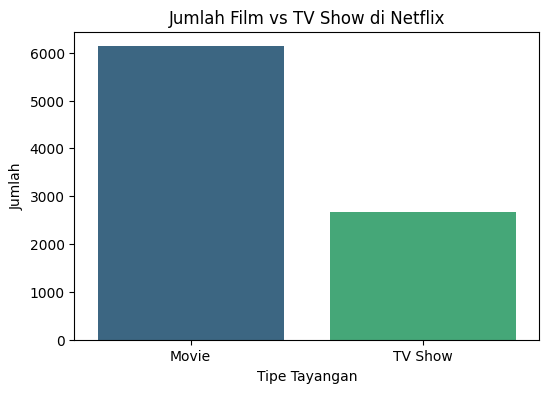

,count
type,
Movie,6131
TV Show,2676


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Jumlah tiap tipe tayangan
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=type_counts.index, y=type_counts.values, palette="viridis")
plt.title("Jumlah Film vs TV Show di Netflix")
plt.xlabel("Tipe Tayangan")
plt.ylabel("Jumlah")
plt.show()

type_counts


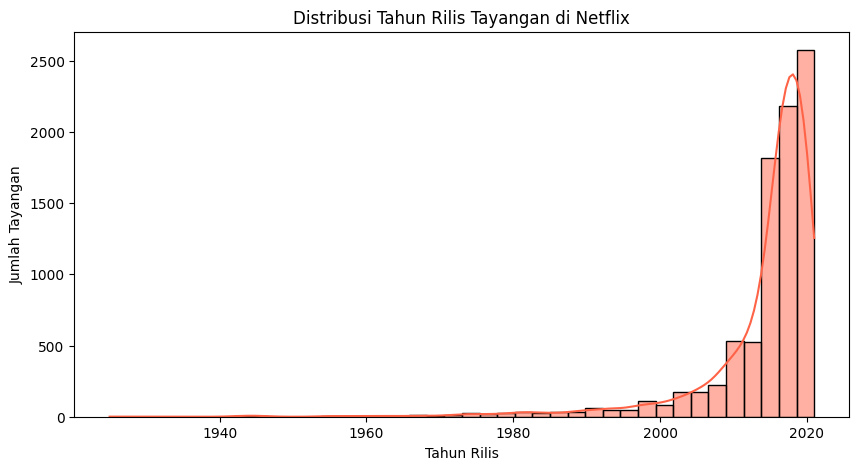

In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'], bins=40, kde=True, color='tomato')
plt.title("Distribusi Tahun Rilis Tayangan di Netflix")
plt.xlabel("Tahun Rilis")
plt.ylabel("Jumlah Tayangan")
plt.show()


/tmp/ipython-input-191152904.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="coolwarm")


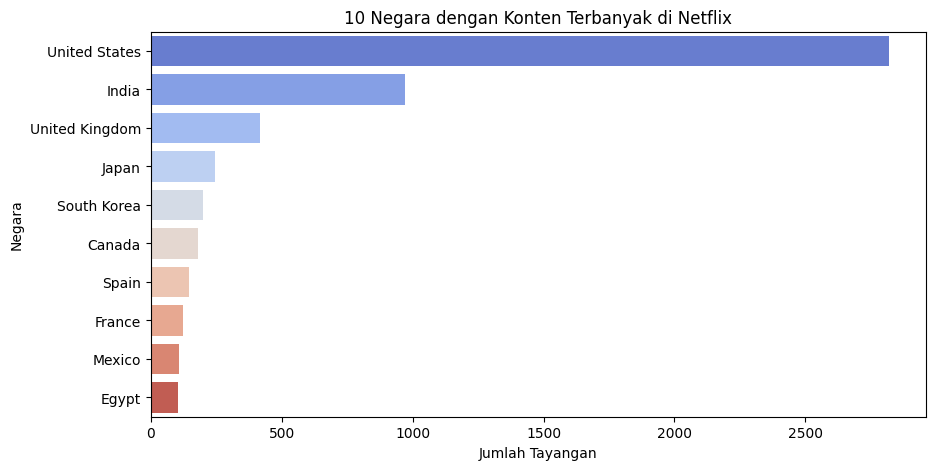

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


In [6]:
# Ambil 10 negara dengan jumlah tayangan terbanyak
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="coolwarm")
plt.title("10 Negara dengan Konten Terbanyak di Netflix")
plt.xlabel("Jumlah Tayangan")
plt.ylabel("Negara")
plt.show()

top_countries


/tmp/ipython-input-293526886.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[g[1] for g in genre_counts], y=[g[0] for g in genre_counts], palette="magma")


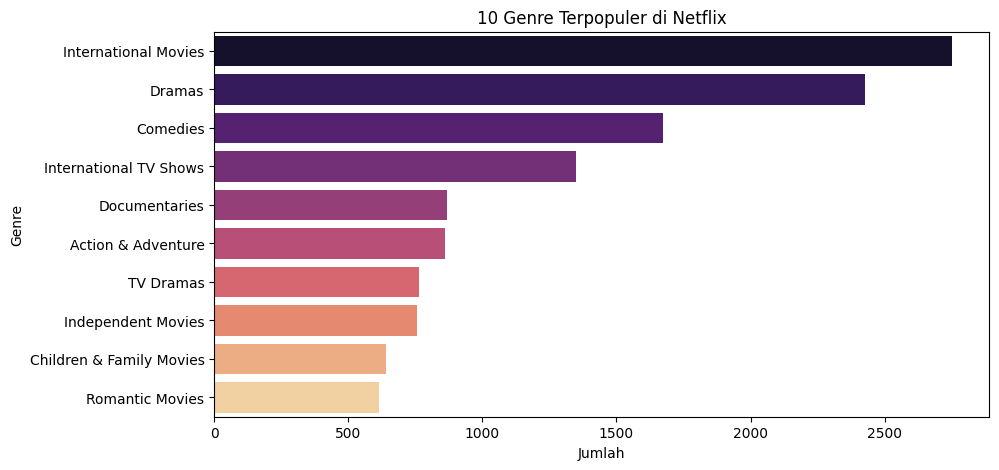

[('International Movies', 2752),
 ('Dramas', 2427),
 ('Comedies', 1674),
 ('International TV Shows', 1351),
 ('Documentaries', 869),
 ('Action & Adventure', 859),
 ('TV Dramas', 763),
 ('Independent Movies', 756),
 ('Children & Family Movies', 641),
 ('Romantic Movies', 616)]

In [7]:
from collections import Counter

# Pisahkan kategori dengan koma dan hitung kemunculan
genres = df['listed_in'].dropna().apply(lambda x: [g.strip() for g in x.split(',')])
all_genres = [genre for sublist in genres for genre in sublist]
genre_counts = Counter(all_genres).most_common(10)

# Visualisasi
plt.figure(figsize=(10,5))
sns.barplot(x=[g[1] for g in genre_counts], y=[g[0] for g in genre_counts], palette="magma")
plt.title("10 Genre Terpopuler di Netflix")
plt.xlabel("Jumlah")
plt.ylabel("Genre")
plt.show()

genre_counts


/tmp/ipython-input-3783937044.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="cubehelix")


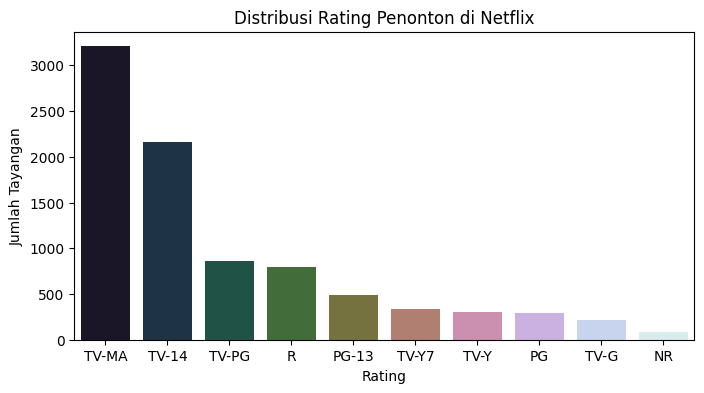

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [8]:
rating_counts = df['rating'].value_counts().head(10)

plt.figure(figsize=(8,4))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="cubehelix")
plt.title("Distribusi Rating Penonton di Netflix")
plt.xlabel("Rating")
plt.ylabel("Jumlah Tayangan")
plt.show()

rating_counts


In [9]:
# Cek kolom dengan missing values lagi
df.isnull().sum()

# Isi missing value dengan string 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

# Pastikan semua sudah terisi
df.isnull().sum()


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [10]:
# Jika 'date_added' tidak Unknown, ubah ke datetime
df['date_added'] = df['date_added'].replace('Unknown', pd.NA)
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Buat kolom baru 'year_added'
df['year_added'] = df['date_added'].dt.year

# Cek hasil
df[['title', 'release_year', 'year_added']].head(10)


,title,release_year,year_added
0,Dick Johnson Is Dead,2020,2021.0
1,Blood & Water,2021,2021.0
2,Ganglands,2021,2021.0
3,Jailbirds New Orleans,2021,2021.0
4,Kota Factory,2021,2021.0
5,Midnight Mass,2021,2021.0
6,My Little Pony: A New Generation,2021,2021.0
7,Sankofa,1993,2021.0
8,The Great British Baking Show,2021,2021.0
9,The Starling,2021,2021.0


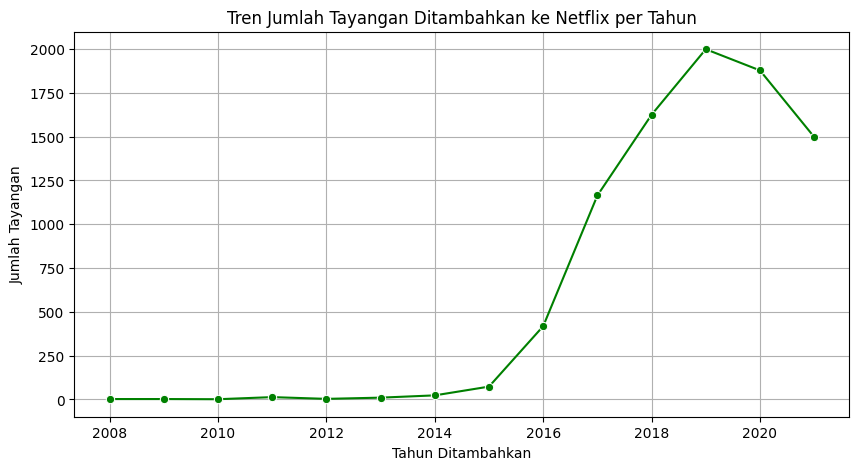

In [11]:
year_added_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.lineplot(x=year_added_counts.index, y=year_added_counts.values, marker='o', color='green')
plt.title("Tren Jumlah Tayangan Ditambahkan ke Netflix per Tahun")
plt.xlabel("Tahun Ditambahkan")
plt.ylabel("Jumlah Tayangan")
plt.grid(True)
plt.show()
